## Analyzing a Compound Dataset

### Imports and data setup

In [1]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors
import matplotlib.pyplot as plt

data = {'SMILES': ['CCO', 'c1ccccc1', 'CC(=O)O', 'CN1C=NC2=C1C(=O)N(C)C(=O)N2C'], 'Activity': [0.5, 0.2, 0.8, 1.2]}
df = pd.DataFrame(data)

### Calculate descriptors

In [2]:
mols = [Chem.MolFromSmiles(smi) for smi in df['SMILES']]
df['MolWt'] = [Descriptors.MolWt(mol) for mol in mols]
df['LogP'] = [Descriptors.MolLogP(mol) for mol in mols]
display(df)

,SMILES,Activity,MolWt,LogP
0,CCO,0.5,46.069,-0.0014
1,c1ccccc1,0.2,78.114,1.6866
2,CC(=O)O,0.8,60.052,0.0909
3,CN1C=NC2=C1C(=O)N(C)C(=O)N2C,1.2,194.194,-1.0293


### Plot data

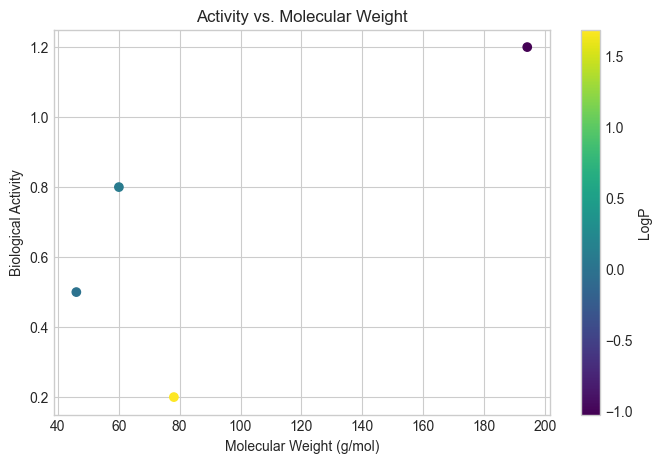

In [3]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(8, 5))
scatter = plt.scatter(df['MolWt'], df['Activity'], c=df['LogP'], cmap='viridis')
plt.xlabel('Molecular Weight (g/mol)')
plt.ylabel('Biological Activity')
plt.title('Activity vs. Molecular Weight')
plt.colorbar(scatter, label='LogP')
plt.show()

## Creating an Interactive Dashboard with Widgets

### Imports

In [8]:
import ipywidgets as widgets
from IPython.display import display

### Create the interactive function

In [10]:
# The 'df' DataFrame from the previous exercise is used here
@widgets.interact(
    molwt_range=widgets.FloatRangeSlider(value=[0, 200], min=0, max=500, step=10, description='MolWt:'),
    logp_range=widgets.FloatRangeSlider(value=[-1, 4], min=-5, max=10, step=0.5, description='LogP:')
)
def filter_molecules(molwt_range, logp_range):
    filtered_df = df[
        (df['MolWt'] >= molwt_range[0]) & (df['MolWt'] <= molwt_range[1]) &
        (df['LogP'] >= logp_range[0]) & (df['LogP'] <= logp_range[1])
    ]
    display(filtered_df)

interactive(children=(FloatRangeSlider(value=(0.0, 200.0), description='MolWt:', max=500.0, step=10.0), FloatR…